# Importing the Relevant Libraries

In [2]:
!pip install -q librosa speechrecognition jiwer gtts


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 135.1 MB/s eta 0:00:00


In [3]:
!pip install -q torch
!apt-get update -qq
!apt-get install -qq ffmpeg


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [4]:
!pip install -q openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [5]:
import numpy as np
import matplotlib.pyplot as plt

import librosa
import librosa.display
import soundfile as sf
import speech_recognition as sr

from jiwer import wer, cer
from IPython.display import Audio

import whisper

import csv
import os
import tempfile
import wave

from gtts import gTTS

In [6]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Loading and Visualizing an Audio File

In [7]:
audio_signal , sample_rate = librosa.load('/content/speech_01.wav',sr=None)

In [8]:
sample_rate

44100

In [9]:
from librosa.core.constantq import audio
plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio_signal,sr=sample_rate)
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()


Audio('/content/speech_01.wav')

Output hidden; open in https://colab.research.google.com to view.

# Transcribing Audio with Google Web Speech API

In [10]:
recognizer = sr.Recognizer()

In [11]:
file_path = '/content/speech_01.wav'

In [12]:
def transcribe_audio(file_path):
  with sr.AudioFile(file_path) as source:
    audio_data = recognizer.record(source)
    text = recognizer.recognize_google(audio_data)
    print(text)
    return text


transcribed_text=transcribe_audio(file_path)

my name is Yvonne and I am excited to have you as part of our Learning Community before we get started I'd like to tell you a little bit about myself I'm a sound engineer turn data scientist curious about machine learning and artificial intelligence my professional background is primarily in media production with a focus on audio it and Communications


In [13]:
ground_truth = """My name is Ivan and I am excited to have you as part of our learning community!
Before we get started, I’d like to tell you a little bit about myself. I’m a sound engineer turned data scientist,
curious about machine learning and Artificial Intelligence. My professional background is primarily in media production,
with a focus on audio, IT, and communications"""

In [14]:
calculated_wer = wer(ground_truth, transcribed_text)
calculated_cer = cer(ground_truth, transcribed_text)
print(f"Word Error Rate (WER): {calculated_wer:.4f}")
print(f"Character Error Rate (CER): {calculated_cer:.4f}")

Word Error Rate (WER): 0.3390
Character Error Rate (CER): 0.0801


# Background Noise and Spectrograms

In [15]:
from librosa.core.constantq import audio
plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio_signal,sr=sample_rate)
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()


Audio('/content/speech_01.wav')

Output hidden; open in https://colab.research.google.com to view.

In [16]:
S  = librosa.stft(audio_signal)

In [17]:
S

array([[-8.67757127e-02+0.0000000e+00j, -2.16521434e-02+0.0000000e+00j,
         4.71511856e-02+0.0000000e+00j, ...,
         0.00000000e+00+0.0000000e+00j,  0.00000000e+00+0.0000000e+00j,
         0.00000000e+00+0.0000000e+00j],
       [ 9.89650860e-02-3.3857092e-02j, -3.12002711e-02+8.8045798e-02j,
        -3.15121226e-02-1.0418473e-02j, ...,
         0.00000000e+00+0.0000000e+00j,  0.00000000e+00+0.0000000e+00j,
         0.00000000e+00+0.0000000e+00j],
       [-1.99844286e-01+1.6290674e-01j,  1.74084887e-01-3.7885439e-02j,
        -4.55934368e-02-6.4477079e-02j, ...,
         0.00000000e+00-0.0000000e+00j,  0.00000000e+00-0.0000000e+00j,
         0.00000000e+00-0.0000000e+00j],
       ...,
       [ 4.24832251e-05-5.6672663e-05j, -3.40010920e-05+7.5565295e-05j,
        -2.43012564e-05-4.2304982e-06j, ...,
         0.00000000e+00+0.0000000e+00j,  0.00000000e+00+0.0000000e+00j,
         0.00000000e+00+0.0000000e+00j],
       [ 2.30733876e-05+5.4863976e-05j,  6.48604691e-05-3.2895885e-0

In [18]:
S_db = librosa.amplitude_to_db(np.abs(S),ref=np.max)

In [19]:
np.max(S_db)

np.float32(0.0)

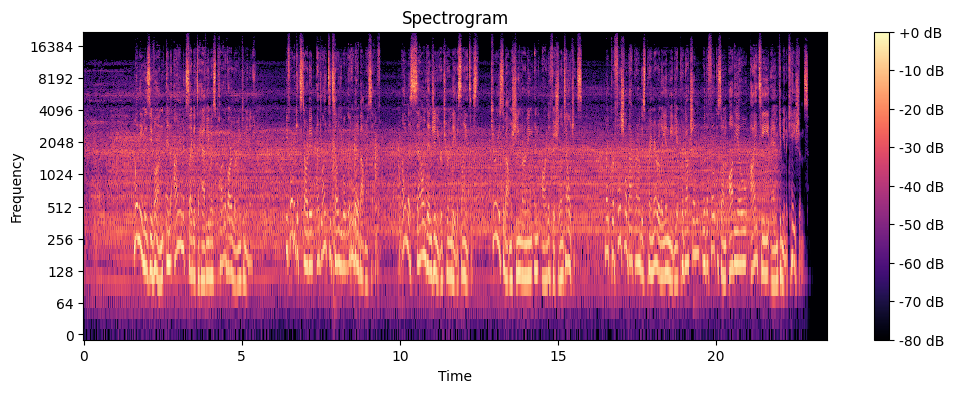

In [20]:
plt.figure(figsize=(12, 4))
librosa.display.specshow(data=S_db,sr=sample_rate,x_axis='time',y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

In [21]:
signal_filtered = librosa.effects.preemphasis(audio_signal,coef=0.97)
sf.write('filtered_speech_01.wav',signal_filtered,sample_rate)
output_file = '/content/filtered_speech_01.wav'

In [22]:
print("original file")
Audio('/content/speech_01.wav')

Output hidden; open in https://colab.research.google.com to view.

In [23]:
print("filtered file")
Audio(output_file)

Output hidden; open in https://colab.research.google.com to view.

In [24]:
Sb = librosa.stft(signal_filtered)

In [25]:
S_dBb = librosa.amplitude_to_db(np.abs(Sb),ref=np.max)

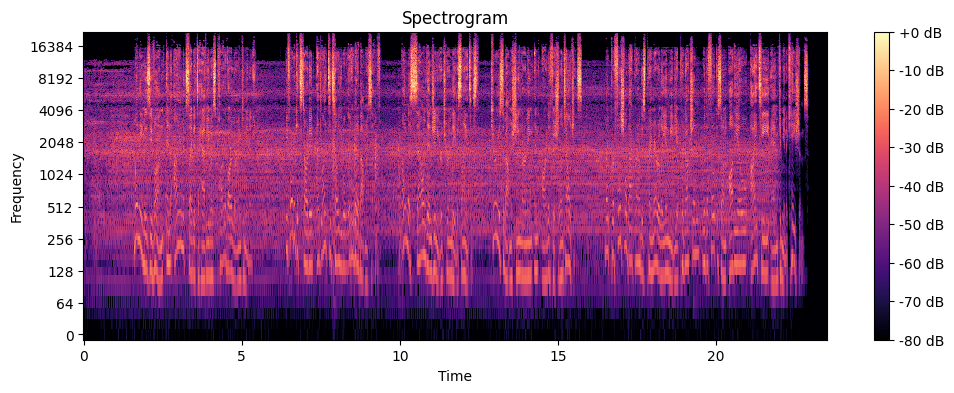

In [26]:
plt.figure(figsize=(12, 4))
librosa.display.specshow(data=S_dBb,sr=sample_rate,x_axis='time',y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

In [27]:
transcribed_text_preemphasis = transcribe_audio('/content/filtered_speech_01.wav')

my name is Yvonne and I am excited to have you as part of our Learning Community before we get started I'd like to tell you a little bit about myself I'm a sound engineer term data scientist curious about machine learning and artificial intelligence my professional background is primarily in media production with a focus on audio it and Communications


In [28]:
calculated_wer = wer(ground_truth, transcribed_text_preemphasis)
calculated_cer = cer(ground_truth, transcribed_text_preemphasis)
print(f"Word Error Rate (WER): {calculated_wer:.4f}")
print(f"Character Error Rate (CER): {calculated_cer:.4f}")

Word Error Rate (WER): 0.3390
Character Error Rate (CER): 0.0856


# Transciribing Audio with OpenAI's Whisper

In [29]:
model = whisper.load_model('large')

100%|█████████████████████████████████████| 2.88G/2.88G [00:33<00:00, 91.1MiB/s]


In [30]:
result = model.transcribe('/content/speech_01.wav')

In [31]:
result

{'text': " My name is Ivan, and I am excited to have you as part of our learning community. Before we get started, I'd like to tell you a little bit about myself. I'm a sound engineer turned data scientist, curious about machine learning and artificial intelligence. My professional background is primarily in media production with a focus on audio, IT, and communications.",
 'segments': [{'id': 0,
   'seek': 0,
   'start': 0.0,
   'end': 5.4,
   'text': ' My name is Ivan, and I am excited to have you as part of our learning community.',
   'tokens': [50365,
    1222,
    1315,
    307,
    28893,
    11,
    293,
    286,
    669,
    2919,
    281,
    362,
    291,
    382,
    644,
    295,
    527,
    2539,
    1768,
    13,
    50635],
   'temperature': 0.0,
   'avg_logprob': -0.15996523256655093,
   'compression_ratio': 1.5338983050847457,
   'no_speech_prob': 0.2796781659126282},
  {'id': 1,
   'seek': 0,
   'start': 6.08,
   'end': 9.26,
   'text': " Before we get started, I'd 

In [32]:
transcribed_text_whisper = result["text"]
print(transcribed_text_whisper)

 My name is Ivan, and I am excited to have you as part of our learning community. Before we get started, I'd like to tell you a little bit about myself. I'm a sound engineer turned data scientist, curious about machine learning and artificial intelligence. My professional background is primarily in media production with a focus on audio, IT, and communications.


In [33]:
result["language"]

'en'

In [34]:
calculated_wer = wer(ground_truth, transcribed_text_whisper)
calculated_cer = cer(ground_truth, transcribed_text_whisper)
print(f"Word Error Rate (WER): {calculated_wer:.4f}")
print(f"Character Error Rate (CER): {calculated_cer:.4f}")

Word Error Rate (WER): 0.1864
Character Error Rate (CER): 0.0304


# Transcribing Multiple Audio Files from a Directory

In [35]:
directory_path = "/content/Recordings"

In [36]:
def transcribe_directory_whisper(directory_path):
    transcriptions = []
    for file_name in os.listdir(directory_path):
        if file_name.endswith(".wav"):
            files_path = os.path.join(directory_path, file_name)
            result = model.transcribe(files_path)
            transcription = result["text"]
            transcriptions.append({"file_name": file_name, "transcription": transcription})
    return transcriptions

In [37]:
transcriptions = transcribe_directory_whisper(directory_path)

In [38]:
transcriptions

[{'file_name': 'Track3.wav',
  'transcription': " Over the years, I've developed a strong interest in digital signal processing, sound and music computing."},
 {'file_name': 'Track5.wav',
  'transcription': ' I believe that nowadays, data is the key to everything.'},
 {'file_name': 'Track4.wav',
  'transcription': ' As a graduate of sound engineering, I make it a priority to strike a balance between art and technology in my work.'},
 {'file_name': 'Track8.wav',
  'transcription': " From the website cookies you've been asked to accept while surfing the web, to the sonification of a supermassive black hole."},
 {'file_name': 'Track7.wav',
  'transcription': ' but it can also give you efficient methodologies for solving problems.'},
 {'file_name': 'Track2.wav',
  'transcription': ' My professional background is primarily in media production with a focus on audio, IT, and communications.'},
 {'file_name': 'Track6.wav',
  'transcription': ' Not only can it provide a rational explanation for

# Saving Audio Transcriptions to CSV for Easy Analysis

In [39]:
output_file = "transcriptions.csv"

with open(output_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Track Number", "File Name", "Transcription"])  # Write the header
    for number, transcription in enumerate(transcriptions, start=1):
        writer.writerow([number, transcription['file_name'], transcription['transcription']])

# Text-to-Speech

In [40]:
text = """I am not in danger, Skyler. I am the danger. A guy opens his door and gets shot, and you think that of me? No! I am the one who knocks!
Yo! yo! yo! 148-3 to the 3 to the 6 to the 9, representing the ABQ, what up, biatch?!
"""

tts = gTTS(text=text, lang='en')
tts.save("output.mp3")

os.system("start output.mp3")

32512

In [41]:
Audio("/content/output.mp3")

In [56]:
import pandas as pd
pd.read_csv("/content/transcriptions.csv")

,Track Number,File Name,Transcription
0,1,Track3.wav,"Over the years, I've developed a strong inter..."
1,2,Track5.wav,"I believe that nowadays, data is the key to e..."
2,3,Track4.wav,"As a graduate of sound engineering, I make it..."
3,4,Track8.wav,From the website cookies you've been asked to...
4,5,Track7.wav,but it can also give you efficient methodolog...
5,6,Track2.wav,My professional background is primarily in me...
6,7,Track6.wav,Not only can it provide a rational explanatio...
7,8,Track1.wav,"I'm a sound engineer turned data scientist, c..."
